### Data Exploration
The purpose is to analyze the data, its statistical properties, find patterns, and perform dimensionality reduction techniques to prepare for model fitting.

In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from scipy.stats import randint, uniform
from sklearn.linear_model import LogisticRegression

In [2]:
star_folder_dir = "data\\star"
galaxy_folder_dir = "data\\galaxy"
star_images = Path(star_folder_dir).glob("*")
galaxy_images = Path(galaxy_folder_dir).glob("*")
star_list = []    
for image in star_images:
    img = Image.open(image).convert("L")
    star_list.append(np.array(img).reshape(-1))
star_df = pd.DataFrame(star_list)
galaxy_list = []
for image in galaxy_images:
    img = Image.open(image).convert("L")
    galaxy_list.append(np.array(img).reshape(-1))
galaxy_df = pd.DataFrame(galaxy_list)


In [3]:
star_df["Type"] = 1
print(f"Shape: {star_df.shape}")
star_df.head()

Shape: (3044, 4097)


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,Type
0,127,65,115,89,78,101,88,111,94,123,...,137,74,84,57,76,82,12,103,99,1
1,118,90,79,87,133,104,110,88,105,81,...,103,92,101,93,84,125,112,107,36,1
2,129,104,99,122,66,127,49,58,70,4,...,88,92,71,90,87,119,93,119,56,1
3,55,28,91,81,47,39,79,101,126,60,...,106,106,80,78,69,147,25,128,65,1
4,106,46,103,68,68,69,131,102,64,104,...,68,81,69,66,89,123,99,148,75,1


In [4]:
galaxy_df["Type"] = 0
print(f"Shape: {galaxy_df.shape}")
galaxy_df.head()

Shape: (942, 4097)


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,Type
0,66,105,128,48,92,93,93,108,62,88,...,73,49,77,115,106,43,97,82,58,0
1,172,140,137,202,81,66,106,78,139,78,...,115,100,127,125,147,131,118,106,103,0
2,114,90,159,127,93,105,95,123,92,111,...,91,60,39,84,95,108,95,80,70,0
3,68,19,104,87,125,84,114,25,86,121,...,109,86,95,111,56,150,74,48,79,0
4,43,97,30,69,74,173,109,96,169,91,...,67,122,78,200,130,101,127,86,122,0


In [5]:
#Combine and shuffle dataframes
df = pd.concat([star_df, galaxy_df]).sample(frac=1, ignore_index=True, random_state=101290365)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,Type
0,101,87,138,106,62,119,74,53,119,97,...,111,117,100,82,88,113,123,107,149,1
1,98,83,108,91,123,92,59,120,85,93,...,120,74,93,103,83,80,123,33,81,0
2,100,52,70,54,82,38,81,93,51,66,...,114,74,100,101,78,51,76,117,35,1
3,30,81,71,57,73,16,64,88,84,100,...,83,57,50,38,83,88,70,35,32,0
4,82,88,94,87,126,30,59,111,112,121,...,100,63,84,86,66,113,76,73,63,1


In [6]:
#Convert into X and y matrices/vectors:
X = df.drop("Type", axis=1)
y = pd.DataFrame(df["Type"])
X.shape, y.shape

((3986, 4096), (3986, 1))

In [7]:
print(f"Means: {X.mean()}, {y.mean()}")
print(f"Variance: {X.var()}")
print(f"Covariance: {X.cov()}")

Means: 0       87.649272
1       86.213497
2       87.753638
3       87.127697
4       86.121425
          ...    
4091    87.484947
4092    87.283492
4093    87.284496
4094    87.005770
4095    86.689915
Length: 4096, dtype: float64, Type    0.763673
dtype: float64
Variance: 0        987.897536
1       1035.420656
2        977.366141
3       1010.172648
4       1020.239205
           ...     
4091    1039.375056
4092    1023.340440
4093    1044.321551
4094    1065.341748
4095    1016.480485
Length: 4096, dtype: float64
Variance: 0        987.897536
1       1035.420656
2        977.366141
3       1010.172648
4       1020.239205
           ...     
4091    1039.375056
4092    1023.340440
4093    1044.321551
4094    1065.341748
4095    1016.480485
Length: 4096, dtype: float64
Covariance:             0            1           2            3            4     \
0     987.897536   215.586316  227.298767   257.423217   203.754517   
1     215.586316  1035.420656  216.314342   222.862567   251.

In [8]:
#Standardizing Data:
transformer = MaxAbsScaler()
X = pd.DataFrame(transformer.fit_transform(X))
print(f"Mean: {X.mean()}")
print(f"Covariance: {X.cov()}")

Mean: 0       0.343723
1       0.338092
2       0.344132
3       0.341677
4       0.340401
          ...   
4091    0.343078
4092    0.342288
4093    0.342292
4094    0.341199
4095    0.339960
Length: 4096, dtype: float64
Covariance:           0         1         2         3         4         5         6     \
0     0.015193  0.003315  0.003496  0.003959  0.003158  0.003092  0.003334   
1     0.003315  0.015923  0.003327  0.003427  0.003892  0.003314  0.003160   
2     0.003496  0.003327  0.015031  0.003480  0.003535  0.003870  0.003409   
3     0.003959  0.003427  0.003480  0.015535  0.003124  0.003452  0.003489   
4     0.003158  0.003892  0.003535  0.003124  0.015939  0.003637  0.003457   
...        ...       ...       ...       ...       ...       ...       ...   
4091  0.000775  0.000584  0.001454  0.000891  0.000793  0.000964  0.000908   
4092  0.001044  0.000830  0.001826  0.000867  0.000655  0.001030  0.001302   
4093  0.001037  0.001270  0.001120  0.001049  0.000834  0.001237

<Axes: >

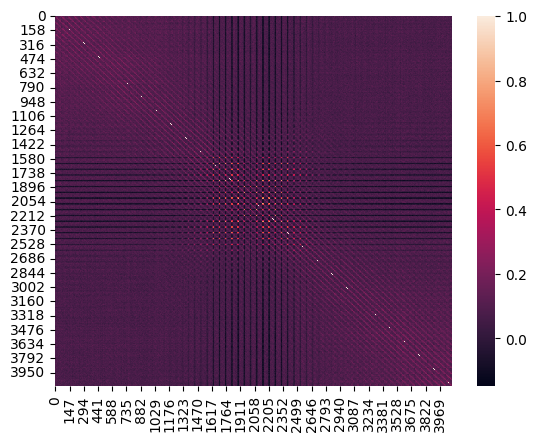

In [9]:
sns.heatmap(X.corr())

High ish correlation in centre variables

In [ ]:
df.columns

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
         4087,   4088,   4089,   4090,   4091,   4092,   4093,   4094,   4095,
       'Type'],
      dtype='object', length=4097)

### PCA
We will attempt to use PCA for our dimensionality reduction. 

c:\Users\gargs\AppData\Local\Programs\Python\Python314\Lib\site-packages\factor_analyzer\factor_analyzer.py:109: RuntimeWarning: divide by zero encountered in log
  statistic = -np.log(corr_det) * (n - 1 - (2 * p + 5) / 6)


Chi-square: inf, P-value: 0.0


c:\Users\gargs\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


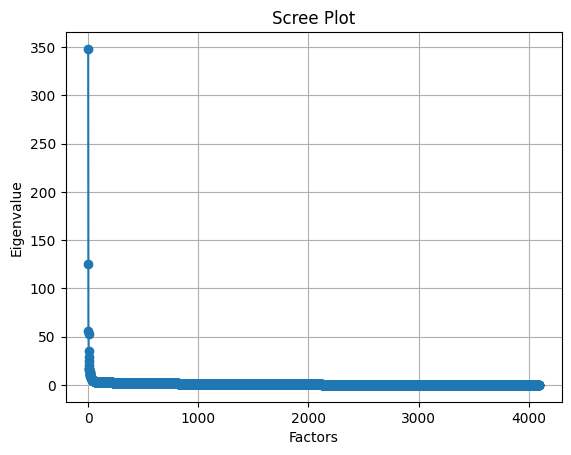

348.261655000503 0
124.86976471717766 1
56.31297664168697 2
52.41583237761288 3
34.68807772776314 4
29.278489867170943 5
24.66962506244523 6
20.803755682671095 7
17.49767470302597 8
16.90787901598941 9
16.31662744297914 10
15.335440501191814 11
13.68033360926224 12
13.492524864513083 13
13.19361062397645 14
11.646553239349887 15
11.266123253805931 16
10.721303779730533 17
10.09396937833659 18
9.776270312269657 19
9.10511009737771 20
8.575321264750679 21
8.45024325180843 22
8.189081941703591 23
7.792518045560836 24
7.67424085035543 25
7.454929445386462 26
7.3611087110676605 27
6.970883912297051 28
6.71258158505812 29
6.600295431410681 30
6.196256115709447 31
6.021607493809526 32
5.926879154213411 33
5.74491133365475 34
5.544381486946044 35
5.459688772659431 36
5.390174022589141 37
5.266413822765404 38
4.950298532761601 39
4.9202828853876674 40
4.786819500413844 41
4.718641721421524 42
4.619058078532813 43
4.566518919503724 44
4.460043166575689 45
4.30757047417866 46
4.289511234171844 47

In [11]:
chi_sq, p = calculate_bartlett_sphericity(X.to_numpy())
print(f'Chi-square: {chi_sq}, P-value: {p}')
fa = FactorAnalyzer(rotation="varimax", method="principal")
fa.fit(X.to_numpy())
eigen_values, _ = fa.get_eigenvalues()
plt.plot(eigen_values, marker='o')
plt.title('Scree Plot'); plt.xlabel('Factors'); plt.ylabel('Eigenvalue'); plt.grid(True); plt.show()
for i, val in enumerate(eigen_values):
    print(val, i)

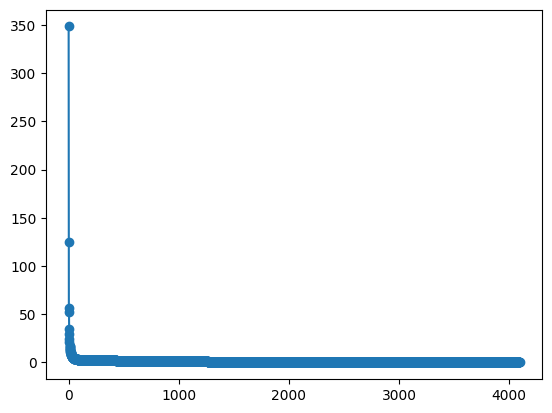

In [12]:

plt.plot(eigen_values, marker='o')


In [13]:
pca_transform = PCA()
pca_transform.fit(X.to_numpy())
pca_transform.explained_variance_ratio_

array([8.78018088e-02, 5.84905836e-02, 1.32909370e-02, ...,
       3.98705657e-08, 3.52904047e-08, 1.59424015e-33], shape=(3986,))

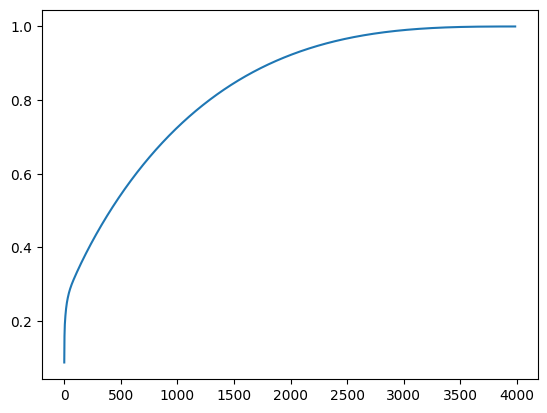

In [14]:
plt.plot(pca_transform.explained_variance_ratio_.cumsum())

In [15]:
pca_true_transform = PCA(n_components=1282)
X_PCA = pca_true_transform.fit_transform(X.to_numpy())

## KNN

We use the K Neighbours Classifier from sci-kit learn to predict the data for astronomy

### Hyperparameter Tuning

Splitting data into training and testing sets and hyperparameter tuning the K using 5-Fold Stratified Cross Validation

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_PCA, y, test_size=0.2, random_state=42, stratify=y)

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

neighbors = np.arange(1, 36)
mean_accuracies = []

for k in neighbors:
    fold_accuracies = []
    for train_index, val_index in skf.split(X_train, y_train):
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        

        n_estimators = 10
        ensemble = []
        for i in range(n_estimators):
            rus = RandomUnderSampler(random_state=i)
            X_res, y_res = rus.fit_resample(X_train_fold, y_train_fold)
            
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_res, y_res.values.ravel())
            ensemble.append(knn)
            
        predictions = np.array([model.predict(X_val_fold) for model in ensemble])
        y_pred_ensemble = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=predictions)
        
        fold_accuracies.append(accuracy_score(y_val_fold, y_pred_ensemble))
        
    mean_accuracies.append(np.mean(fold_accuracies))


best_k = neighbors[np.argmax(mean_accuracies)]
print(f"Best number of neighbors (k): {best_k}")
print(f"Best cross-validation accuracy: {max(mean_accuracies)}")

Best number of neighbors (k): 35
Best cross-validation accuracy: 0.7547058852477572


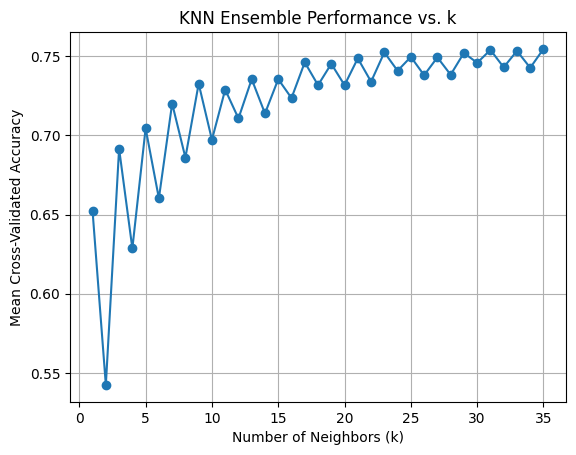

In [20]:
plt.plot(neighbors, mean_accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Cross-Validated Accuracy')
plt.title('KNN Ensemble Performance vs. k')
plt.grid(True)
plt.show()

We can see the performance converges to around 75% and as 27 gives us the best accuracy we use that for our K

In [21]:
final_ensemble = []
n_estimators = 10


for i in range(n_estimators):
    rus = RandomUnderSampler(random_state=i)
    X_res, y_res = rus.fit_resample(X_train, y_train)
    
    knn = KNeighborsClassifier(n_neighbors=19)
    knn.fit(X_res, y_res.values.ravel())
    final_ensemble.append(knn)

predictions = np.array([model.predict(X_test) for model in final_ensemble])
y_pred_test = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=predictions)

print("Classification Results on Test Set:")
print(classification_report(y_test, y_pred_test))

Classification Results on Test Set:
              precision    recall  f1-score   support

           0       0.49      0.44      0.46       189
           1       0.83      0.86      0.84       609

    accuracy                           0.76       798
   macro avg       0.66      0.65      0.65       798
weighted avg       0.75      0.76      0.75       798



# Random forest implementation

### Split Data

In [ ]:
# Split X_PCA and y
X_PCA_train, X_PCA_test, y_train, y_test = train_test_split(X_PCA, y, test_size=0.2, random_state=42)

print("Shape of X_PCA_train:", X_PCA_train.shape)
print("Shape of X_PCA_test:", X_PCA_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_PCA_train: (3188, 1282)
Shape of X_PCA_test: (798, 1282)
Shape of y_train: (3188, 1)
Shape of y_test: (798, 1)


## Initial model: a simple (regular) RF model

### Random Forest on PCA Data


In [ ]:
model_RF_PCA_final = RandomForestClassifier(n_estimators=100, criterion='entropy', min_samples_leaf=2, random_state=42)
model_RF_PCA_final.fit(X_PCA_train, y_train.values.ravel())
y_train_pred = model_RF_PCA_final.predict(X_PCA_train)
y_pred_1 = model_RF_PCA_final.predict(X_PCA_test)

print(f"  Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  Testing Accuracy: {accuracy_score(y_test, y_pred_1):.4f}")
print("Classification Report (PCA):\n", classification_report(y_test, y_pred_1, zero_division=0))
print("Confusion Matrix (PCA):\n", confusion_matrix(y_test, y_pred_1))

  Training Accuracy: 1.0000
  Testing Accuracy: 0.7757
Classification Report (PCA):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       179
           1       0.78      1.00      0.87       619

    accuracy                           0.78       798
   macro avg       0.39      0.50      0.44       798
weighted avg       0.60      0.78      0.68       798

Confusion Matrix (PCA):
 [[  0 179]
 [  0 619]]


Although the accuracies seem to be high, a likely underlying reason is that since the dataset is imbalanced, the model simply keeps predicting class label = 1 (star) all the time, as we can see in the classification report and the confusion matrix.

### Analyze Class Distribution


In [ ]:
print("Class distribution in y_train:")
print(y_train.value_counts())

print("\nClass distribution in y_test:")
print(y_test.value_counts())

Class distribution in y_train:
Type
1       2425
0        763
Name: count, dtype: int64

Class distribution in y_test:
Type
1       619
0       179
Name: count, dtype: int64


## Train Models with Class Weighting


We retrain the Random Forest classifiers for the preprocessed dataset by using the `BalancedRandomForestClassifier` method.

### New training model with balance


This time we use stratified K-fold to choose the best set of hyperparameter.

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

n_estimators_list = [200, 400]
max_depth_list = [None, 10, 20]
min_samples_split_list = [2, 5, 10]
min_samples_leaf_list = [1, 2, 4]

configs = []
mean_accuracies = []

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for n_est in n_estimators_list:
    for md in max_depth_list:
        for mss in min_samples_split_list:
            for msl in min_samples_leaf_list:
                fold_accuracies = []
                print(f"\nNow fitting: n_est = {n_est}, max_depth = {md}, mss = {mss}, msl = {msl} ")

                # Inner CV loop
                for train_index, val_index in skf.split(X_PCA_train, y_train):
                    X_train_fold, X_val_fold = X_PCA_train[train_index], X_PCA_train[val_index]
                    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

                    brf = BalancedRandomForestClassifier(
                        n_estimators=n_est,
                        max_depth=md,
                        min_samples_split=mss,
                        min_samples_leaf=msl,
                        criterion='entropy',
                        n_jobs=-1,
                        random_state=42
                    )
                    brf.fit(X_train_fold, y_train_fold.values.ravel())
                    y_val_pred = brf.predict(X_val_fold)
                    acc = accuracy_score(y_val_fold, y_val_pred)
                    fold_accuracies.append(acc)
                    # Print classification report for each fold:
                    print(classification_report(y_val_fold, y_val_pred))

                mean_acc = np.mean(fold_accuracies)
                configs.append({
                    "n_estimators": n_est,
                    "max_depth": md,
                    "min_samples_split": mss,
                    "min_samples_leaf": msl
                })
                print("Mean accuracy:", mean_acc)
                mean_accuracies.append(mean_acc)

# Select best configuration
best_idx = int(np.argmax(mean_accuracies))
best_params = configs[best_idx]
best_cv_acc = mean_accuracies[best_idx]

print("Best params:", best_params)
print("Best cross-validation accuracy:", best_cv_acc)


Now fitting: n_est = 200, max_depth = None, mss = 2, msl = 1 
              precision    recall  f1-score   support

           0       0.54      0.21      0.30       153
           1       0.79      0.94      0.86       485

    accuracy                           0.77       638
   macro avg       0.67      0.58      0.58       638
weighted avg       0.73      0.77      0.73       638

              precision    recall  f1-score   support

           0       0.47      0.16      0.24       153
           1       0.78      0.94      0.85       485

    accuracy                           0.76       638
   macro avg       0.63      0.55      0.54       638
weighted avg       0.71      0.76      0.71       638

              precision    recall  f1-score   support

           0       0.53      0.16      0.24       153
           1       0.78      0.96      0.86       485

    accuracy                           0.76       638
   macro avg       0.66      0.56      0.55       638
weighted av

### Fitting the final model and evaluation

In [ ]:
brf = BalancedRandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    criterion='entropy',
    n_jobs=-1,
    random_state=42
)
brf.fit(X_PCA_train, y_train.values.ravel())
y_pred_2 = brf.predict(X_PCA_test)
acc = accuracy_score(y_test, y_pred_2)

print("Accuracy:", acc)
print("Classification Report:\n", classification_report(y_test, y_pred_2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_2))

Accuracy: 0.7669172932330827
Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.10      0.16       179
           1       0.79      0.96      0.86       619

    accuracy                           0.77       798
   macro avg       0.60      0.53      0.51       798
weighted avg       0.70      0.77      0.71       798

Confusion Matrix:
 [[ 18 161]
 [ 25 594]]


In [ ]:
# Predict probabilities for class 1
y_proba = brf.predict_proba(X_PCA_test)[:, 1]

# Set a lower threshold
threshold = 0.55
y_pred_3 = (y_proba >= threshold).astype(int)

acc = accuracy_score(y_test, y_pred_3)
print("Accuracy:", acc)

print("Classification Report:")
print(classification_report(y_test, y_pred_3))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_3))

Accuracy: 0.7593984962406015
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.57      0.52       179
           1       0.87      0.81      0.84       619

    accuracy                           0.76       798
   macro avg       0.67      0.69      0.68       798
weighted avg       0.78      0.76      0.77       798

Confusion Matrix:
[[102  77]
 [115 504]]


### Visualizing balancing improvement



In [ ]:
def get_metrics(y_true, y_pred, model_name, weighted=False):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    metrics = {
        'model': model_name,
        'weighted': weighted,
        'accuracy': report['accuracy'],
        'precision_0': report['0']['precision'],
        'recall_0': report['0']['recall'],
        'f1_0': report['0']['f1-score'],
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1_1': report['1']['f1-score'],
    }
    return metrics

# Collect metrics for all models
all_metrics = []

# Classic Model
all_metrics.append(get_metrics(y_test, y_pred_1, 'Classic Model'))

# Balanced Model - Normal Threshold
all_metrics.append(get_metrics(y_test, y_pred_2, 'Balanced Model - Normal Threshold'))

# Balanced Model - High Threshold
all_metrics.append(get_metrics(y_test, y_pred_3, 'Balanced Model - High Threshold'))

# Convert to DataFrame for better display
metrics_df = pd.DataFrame(all_metrics)

# Display the metrics
print("\n--- Performance Metrics Comparison ---")
print(metrics_df.to_string())



--- Performance Metrics Comparison ---
                               model  weighted  accuracy  precision_0  recall_0      f1_0  precision_1  recall_1      f1_1
0                      Classic Model     False  0.775689     0.000000  0.000000  0.000000     0.775689  1.000000  0.873677
1  Balanced Model - Normal Threshold     False  0.766917     0.418605  0.100559  0.162162     0.786755  0.959612  0.864629
2    Balanced Model - High Threshold     False  0.759398     0.470046  0.569832  0.515152     0.867470  0.814216  0.840000


### Visualize Performance Metrics

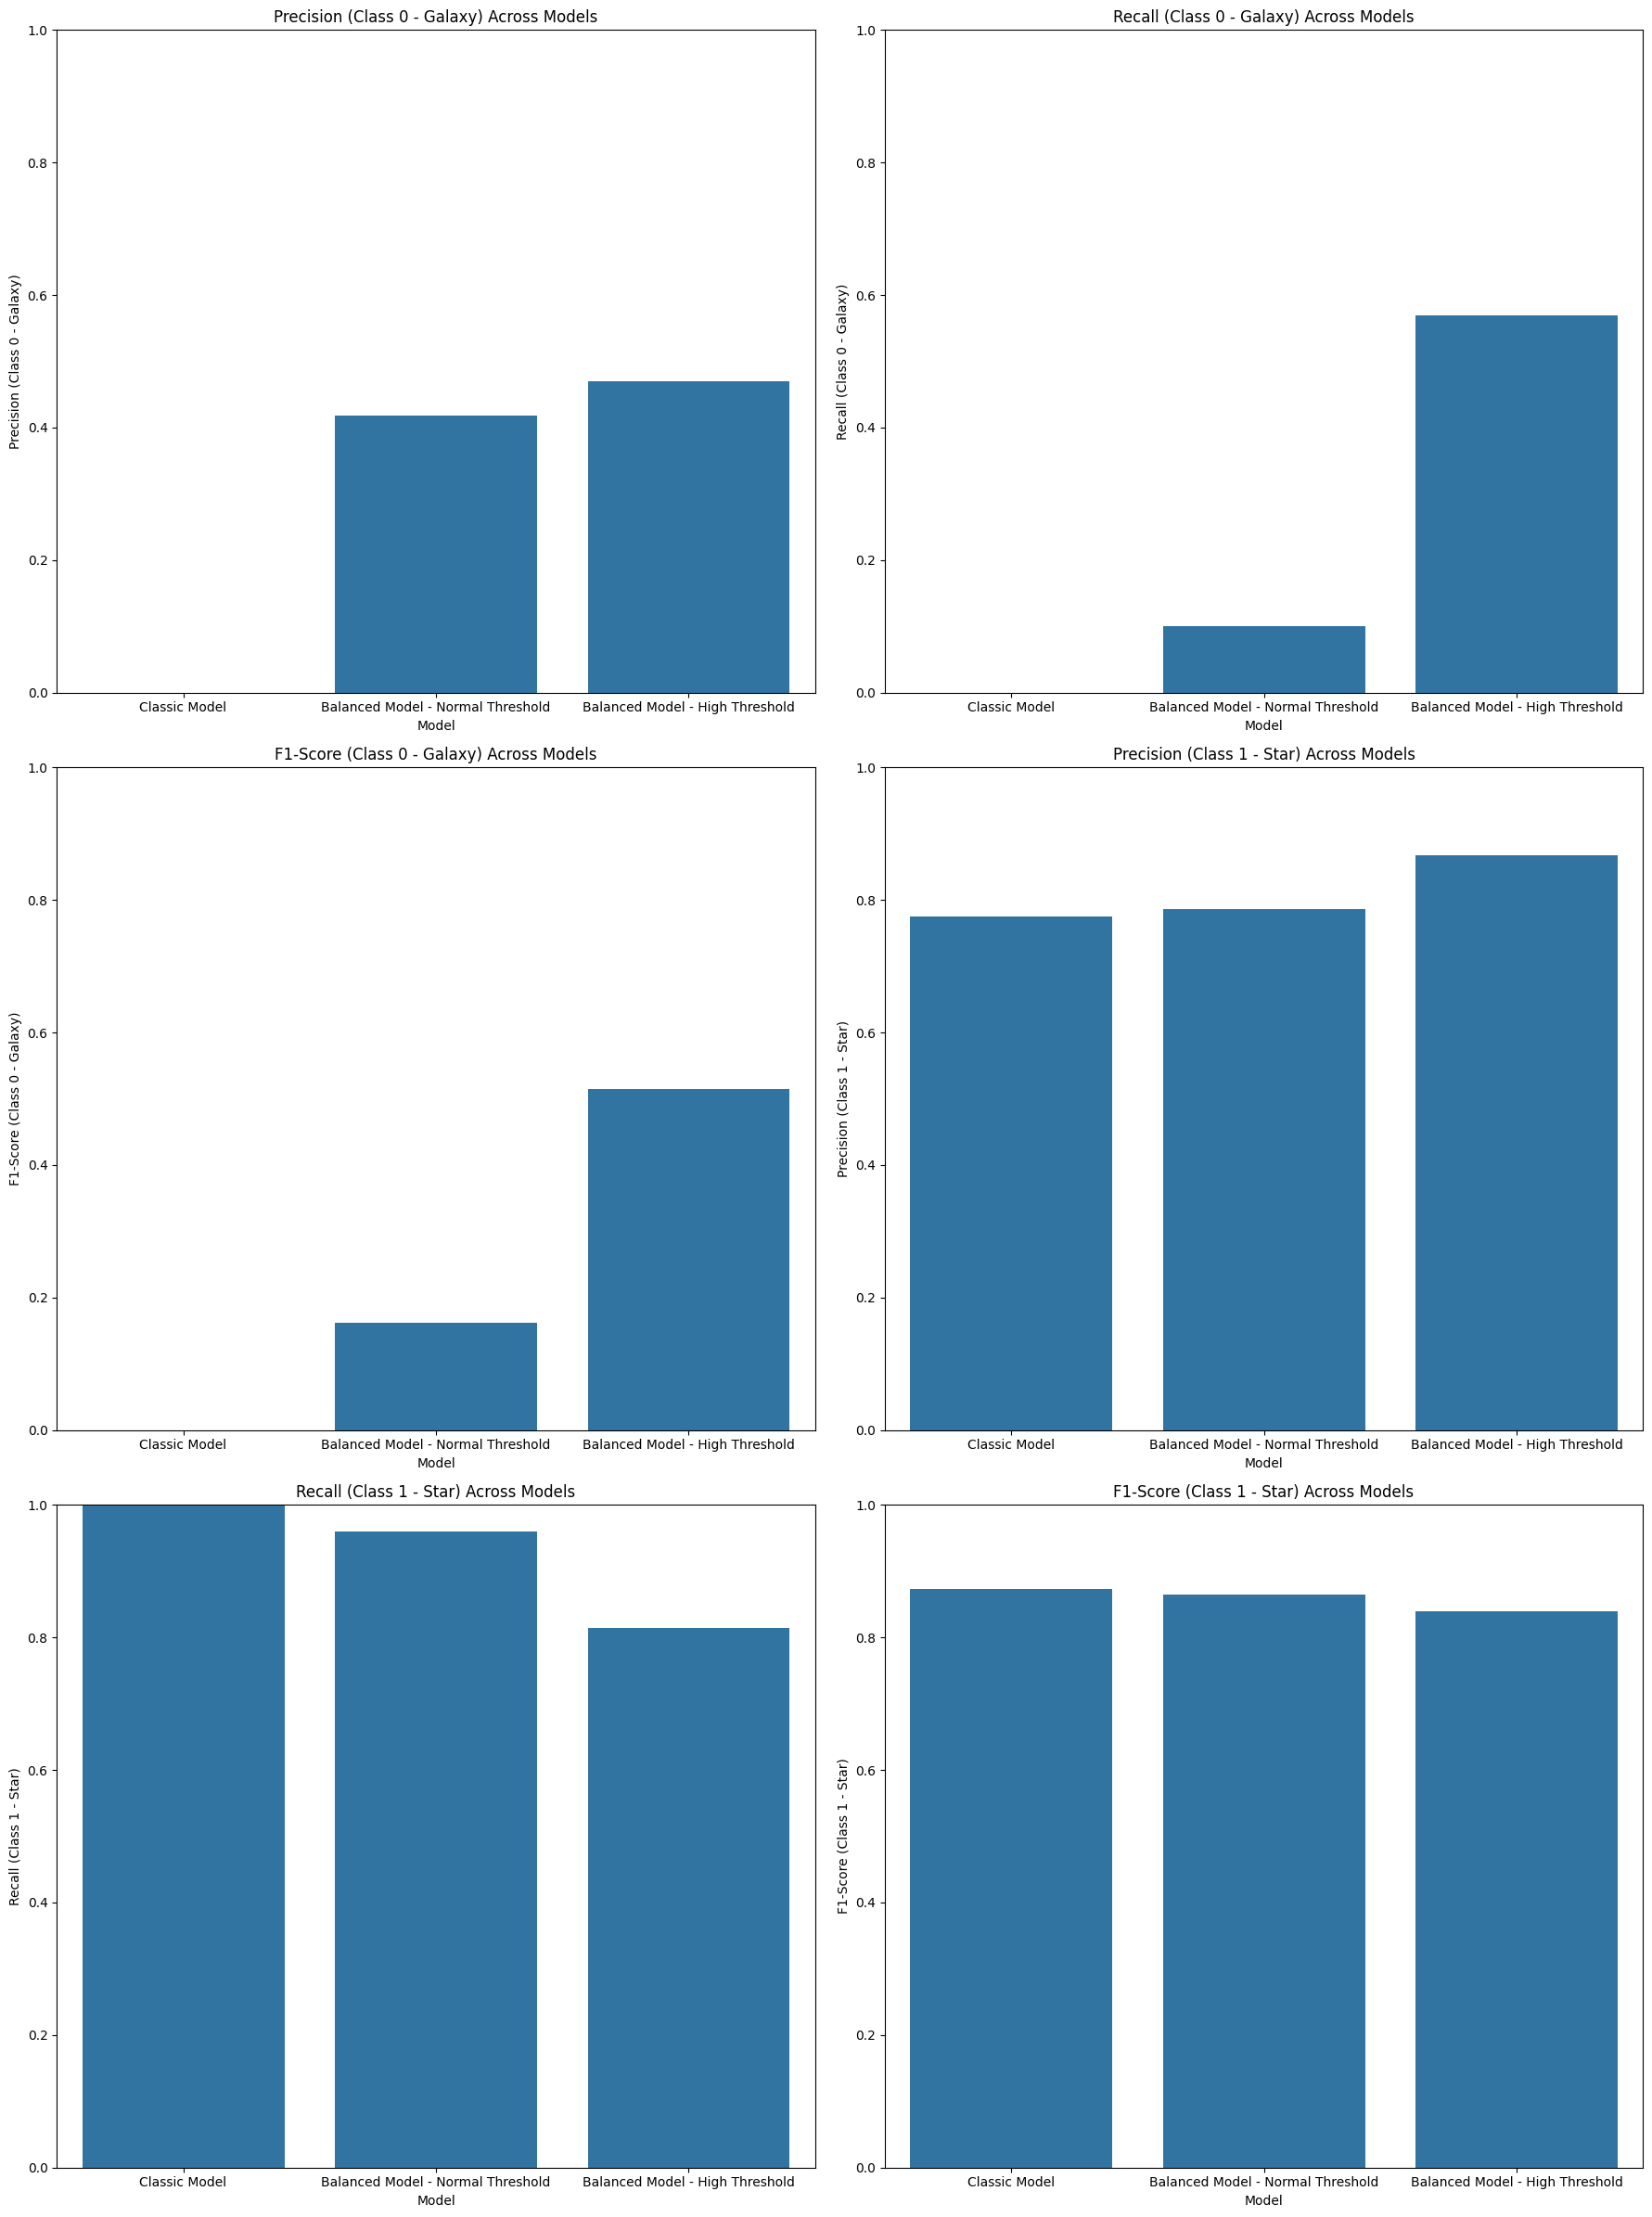

Visualizations of performance metrics generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = {
    'precision_0': 'Precision (Class 0 - Galaxy)',
    'recall_0': 'Recall (Class 0 - Galaxy)',
    'f1_0': 'F1-Score (Class 0 - Galaxy)',
    'precision_1': 'Precision (Class 1 - Star)',
    'recall_1': 'Recall (Class 1 - Star)',
    'f1_1': 'F1-Score (Class 1 - Star)'
}

plt.figure(figsize=(18, 24))
plot_num = 1

for metric_col, title_text in metrics_to_plot.items():
    plt.subplot(3, 2, plot_num)
    sns.barplot(x='model', y=metric_col, data=metrics_df)
    plt.title(f'{title_text} Across Models')
    plt.xlabel('Model')
    plt.ylabel(title_text)
    plt.ylim(0, 1) # Metrics are between 0 and 1
    plot_num += 1

plt.tight_layout()
plt.show()

print("Visualizations of performance metrics generated.")

## Logistics Regression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_PCA, y)

In [ ]:
glm = LogisticRegression(solver="newton-cholesky")
glm.fit(X_train, y_train)
preds = glm.predict(X_test)
1 - (preds - y_test.to_numpy()).mean()  #Hey that aint bad

c:\Users\burha\miniconda3\envs\py313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


np.float64(0.9608826479438315)

## CNN

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# Load the standardized data saved in the previous cells
# We use X.npy (raw pixels) instead of X_PCA.npy because CNNs need spatial features
X = np.load('X.npy') #
y = np.load('y.npy') #

# Calculate image dimensions
# The notebook flattened images via .reshape(-1)
# We assume square images: sqrt(number of columns)
num_features = X.shape[1]
img_dim = int(np.sqrt(num_features))

print(f"Detected Image Resolution: {img_dim}x{img_dim}")

# Reshape X into (Batch_Size, Height, Width, Channels)
# Channels = 1 because the notebook converts images to "L" (Grayscale)
X_cnn = X.reshape(-1, img_dim, img_dim, 1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y, test_size=0.2, random_state=42)

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Detected Image Resolution: 64x64
Training Shape: (3188, 64, 64, 1)
Testing Shape: (798, 64, 64, 1)


In [ ]:
def build_simple_cnn(input_shape):
    model = models.Sequential()

    # Convolutional Block 1
    # Extracts low-level features (edges, curves)
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 2
    # Extracts higher-level features
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Convolutional Block 3 (Optional, adds depth)
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))

    # Flattening
    # Converts 2D feature maps to 1D vector for the Dense layers
    model.add(layers.Flatten())

    # Dense Layers (Classifier)
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5)) # Helps prevent overfitting

    # Output Layer
    # Single neuron with sigmoid activation for binary classification (Star vs Galaxy)
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

model = build_simple_cnn((img_dim, img_dim, 1))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645,697 (2.46 MB)

 Trainable params: 645,697 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=15,             # Adjust epochs based on convergence
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 186ms/step - accuracy: 0.7476 - loss: 0.5840 - val_accuracy: 0.7757 - val_loss: 0.5576
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 177ms/step - accuracy: 0.7775 - loss: 0.5521 - val_accuracy: 0.7757 - val_loss: 0.4924
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step - accuracy: 0.7743 - loss: 0.4591 - val_accuracy: 0.8709 - val_loss: 0.3709
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step - accuracy: 0.8128 - loss: 0.3745 - val_accuracy: 0.8509 - val_loss: 0.3344
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step - accuracy: 0.8601 - loss: 0.3338 - val_accuracy: 0.8847 - val_loss: 0.2966
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 178ms/step - accuracy: 0.8502 - loss: 0.3304 - val_accuracy: 0.8622 - val_loss: 0.3473
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - accuracy: 0.8701 - loss: 0.3207 - val_accuracy: 0.8784 - val_loss: 0.3136
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 186ms/step - accuracy: 0.8729 - loss: 0

25/25 - 1s - 50ms/step - accuracy: 0.8810 - loss: 0.2827

Test accuracy: 0.8810


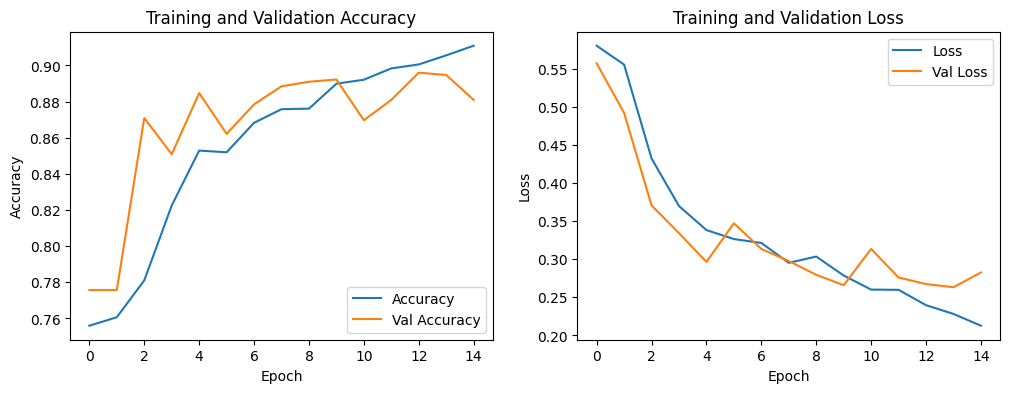

In [ ]:
import matplotlib.pyplot as plt

# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label = 'Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
Classification Report:

                  precision    recall  f1-score   support

Galaxy (Class 0)       0.74      0.73      0.73       179
  Star (Class 1)       0.92      0.92      0.92       619

        accuracy                           0.88       798
       macro avg       0.83      0.83      0.83       798
    weighted avg       0.88      0.88      0.88       798



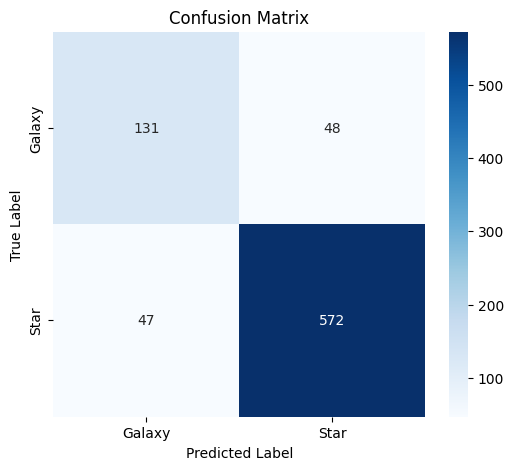

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate predictions on the test set
y_pred_probs = model.predict(X_test)

# 2. Convert probabilities to binary classes (Threshold = 0.5)
# If probability > 0.5, classify as 1 (Star), else 0 (Galaxy)
y_pred = (y_pred_probs > 0.5).astype("int32")

# 3. Print Classification Report
# We map 0 -> Galaxy and 1 -> Star based on the original dataframe setup
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Galaxy (Class 0)', 'Star (Class 1)']))

# 4. Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Galaxy', 'Star'],
            yticklabels=['Galaxy', 'Star'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()